# GWHD 2021: Hard Image Distribution Across Domains

Inspect whether hard images (high difficulty scores) cluster in minority domains.
This is the stochastic instability diagnostic: if hard images concentrate in underrepresented domains,
score-guided augmentation will create high-variance training signals sensitive to sampling order.

In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load the designed difficulty scores
score_path = Path('/home/khanh/Projects/DifficultyAgri/results/02_only_scoring_gwhd_2021/Step_3_Scoring_Dataset/score_results.json')
with open(score_path) as f:
    score_data = json.load(f)

# Load training CSV to get domain labels
train_csv = Path('/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/raw_v2/gwhd_2021/competition_train.csv')
train_df = pd.read_csv(train_csv)

print(f"Loaded {len(score_data['image_difficulties'])} images with difficulty scores")
print(f"Training CSV has {len(train_df)} rows")
print(f"\nColumns in train CSV: {train_df.columns.tolist()}")
print(f"Unique domains: {train_df['domain'].nunique()}")

Loaded 3655 images with difficulty scores
Training CSV has 3657 rows

Columns in train CSV: ['image_name', 'BoxesString', 'domain']
Unique domains: 18


In [11]:
# Map image filenames to domains from CSV
filename_to_domain = dict(zip(train_df['image_name'], train_df['domain']))

# Build table: image path -> difficulty score -> domain
image_scores = []
for img_entry in score_data['image_difficulties']:
    img_path = img_entry['image_path']
    filename = Path(img_path).name
    diff_score = img_entry['difficulty_score']
    domain = filename_to_domain.get(filename)
    if domain:  # Only include images with known domains
        image_scores.append({
            'filename': filename,
            'difficulty_score': diff_score,
            'domain': domain
        })

df_scores = pd.DataFrame(image_scores)
print(f"Total images with domain labels: {len(df_scores)}")

# Calculate domain statistics
domain_stats = df_scores.groupby('domain').agg({
    'difficulty_score': ['count', 'mean', 'std', 'min', 'max'],
}).round(4)
domain_stats.columns = ['n_images', 'mean_difficulty', 'std_difficulty', 'min_difficulty', 'max_difficulty']
domain_stats = domain_stats.sort_values('n_images', ascending=False)

print("\nDomain Statistics (sorted by image count):")
print(domain_stats)

# Identify minority domains: bottom 33% by image count
domain_counts = df_scores['domain'].value_counts().sort_values()
threshold_33pct = domain_counts.quantile(0.33)
minority_domains = domain_counts[domain_counts <= threshold_33pct].index.tolist()

print(f"\n=== Minority Domains (bottom 33%) ===")
print(f"Threshold: <= {threshold_33pct:.0f} images")
print(f"Minority domains: {minority_domains}")
print(f"Count: {len(minority_domains)}/{len(domain_stats)}")


Total images with domain labels: 3655

Domain Statistics (sorted by image count):
                n_images  mean_difficulty  std_difficulty  min_difficulty  \
domain                                                                      
ETHZ_1               747           0.2699          0.0424          0.1391   
Arvalis_3            588           0.3567          0.0567          0.2201   
Arvalis_5            448           0.3490          0.1628          0.0000   
Rres_1               432           0.2324          0.0440          0.1495   
Arvalis_2            401           0.3964          0.0776          0.2559   
Arvalis_4            204           0.4987          0.0999          0.2907   
Inrae_1              176           0.2823          0.0824          0.1687   
Arvalis_6            160           0.2908          0.0445          0.1894   
NMBU_2                98           0.3546          0.2036          0.1802   
NMBU_1                82           0.3404          0.0518          0.25

In [12]:
# Identify hard images: top 33% (tertile) by difficulty score
hard_threshold = df_scores['difficulty_score'].quantile(0.67)
df_scores['is_hard'] = df_scores['difficulty_score'] >= hard_threshold
df_scores['is_minority_domain'] = df_scores['domain'].isin(minority_domains)

hard_images = df_scores[df_scores['is_hard']]
print(f"\n=== Hard Images Analysis ===")
print(f"Hard image threshold (67th percentile): {hard_threshold:.4f}")
print(f"Total hard images: {len(hard_images)}/{len(df_scores)} ({100*len(hard_images)/len(df_scores):.1f}%)")

# How many hard images are in minority domains?
hard_in_minority = hard_images['is_minority_domain'].sum()
hard_in_majority = (~hard_images['is_minority_domain']).sum()
pct_hard_in_minority = 100 * hard_in_minority / len(hard_images)

print(f"\nHard images distribution:")
print(f"  - In minority domains: {hard_in_minority} ({pct_hard_in_minority:.1f}%)")
print(f"  - In majority domains: {hard_in_majority} ({100-pct_hard_in_minority:.1f}%)")

# Compare with baseline: if hard images were uniform, what % would be in minority?
total_in_minority = df_scores['is_minority_domain'].sum()
total_in_majority = (~df_scores['is_minority_domain']).sum()
pct_minority = 100 * total_in_minority / len(df_scores)

print(f"\nBaseline: {pct_minority:.1f}% of all images are in minority domains")
print(f"Concentration ratio: hard images are {pct_hard_in_minority/pct_minority:.2f}x overrepresented in minority domains")

if pct_hard_in_minority > 50:
    print("\n✓ STOCHASTIC INSTABILITY SYMPTOM DETECTED: Hard images concentrate in minority domains")
else:
    print("\n✗ No strong concentration: Hard images are NOT concentrated in minority domains")



=== Hard Images Analysis ===
Hard image threshold (67th percentile): 0.3585
Total hard images: 1206/3655 (33.0%)

Hard images distribution:
  - In minority domains: 94 (7.8%)
  - In majority domains: 1112 (92.2%)

Baseline: 5.3% of all images are in minority domains
Concentration ratio: hard images are 1.48x overrepresented in minority domains

✗ No strong concentration: Hard images are NOT concentrated in minority domains



=== Hard Image % by Domain (sorted) ===
                n_hard  n_total   pct_hard  is_minority
domain                                                 
Arvalis_4          196      204  96.078431        False
ULiège-GxABT_1      27       30  90.000000         True
Arvalis_12          23       29  79.310345         True
Arvalis_7           17       24  70.833333         True
Arvalis_2          277      401  69.077307        False
Arvalis_1           45       66  68.181818        False
Arvalis_9           18       32  56.250000         True
Arvalis_11          30       60  50.000000        False
Arvalis_3          259      588  44.047619        False
Arvalis_5          192      448  42.857143        False
Arvalis_8            8       20  40.000000         True
NMBU_1              31       82  37.804878        False
NMBU_2              24       98  24.489796        False
Inrae_1             24      176  13.636364        False
Arvalis_6           10      160   6.250000        False
ETHZ_1 

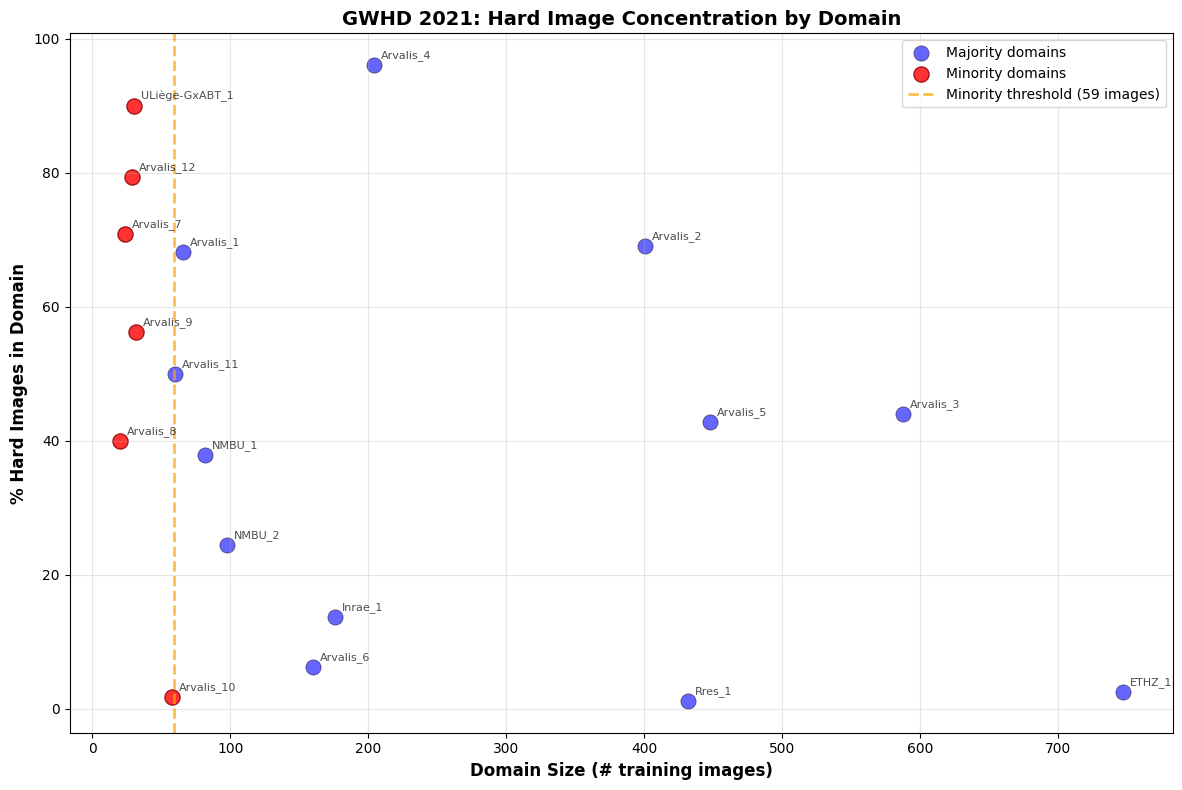

In [13]:
# Build domain breakdown: count of hard vs non-hard in each domain
domain_breakdown = df_scores.groupby('domain').agg({
    'is_hard': 'sum',
    'domain': 'count'
}).rename(columns={'is_hard': 'n_hard', 'domain': 'n_total'})
domain_breakdown['pct_hard'] = 100 * domain_breakdown['n_hard'] / domain_breakdown['n_total']
domain_breakdown['is_minority'] = domain_breakdown.index.isin(minority_domains)
domain_breakdown = domain_breakdown.sort_values('pct_hard', ascending=False)

print("\n=== Hard Image % by Domain (sorted) ===")
print(domain_breakdown)

# Scatter plot: domain size vs % hard
fig, ax = plt.subplots(figsize=(12, 8))

minority_df = domain_breakdown[domain_breakdown['is_minority']]
majority_df = domain_breakdown[~domain_breakdown['is_minority']]

ax.scatter(majority_df['n_total'], majority_df['pct_hard'], 
          s=120, alpha=0.6, c='blue', edgecolors='black', linewidth=0.5, label='Majority domains')
ax.scatter(minority_df['n_total'], minority_df['pct_hard'], 
          s=120, alpha=0.8, c='red', edgecolors='darkred', linewidth=1, label='Minority domains')

# Add domain labels
for idx, row in domain_breakdown.iterrows():
    ax.annotate(idx, (row['n_total'], row['pct_hard']), 
               xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

ax.axvline(threshold_33pct, color='orange', linestyle='--', linewidth=2, alpha=0.7, label=f'Minority threshold ({threshold_33pct:.0f} images)')
ax.set_xlabel('Domain Size (# training images)', fontsize=12, fontweight='bold')
ax.set_ylabel('% Hard Images in Domain', fontsize=12, fontweight='bold')
ax.set_title('GWHD 2021: Hard Image Concentration by Domain', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_hard_image_by_domain.png', dpi=200, bbox_inches='tight')
print(f"\nSaved plot to results/gwhd_2021_hard_image_by_domain.png")
plt.show()


Saved summary plot to results/gwhd_2021_hard_image_summary.png


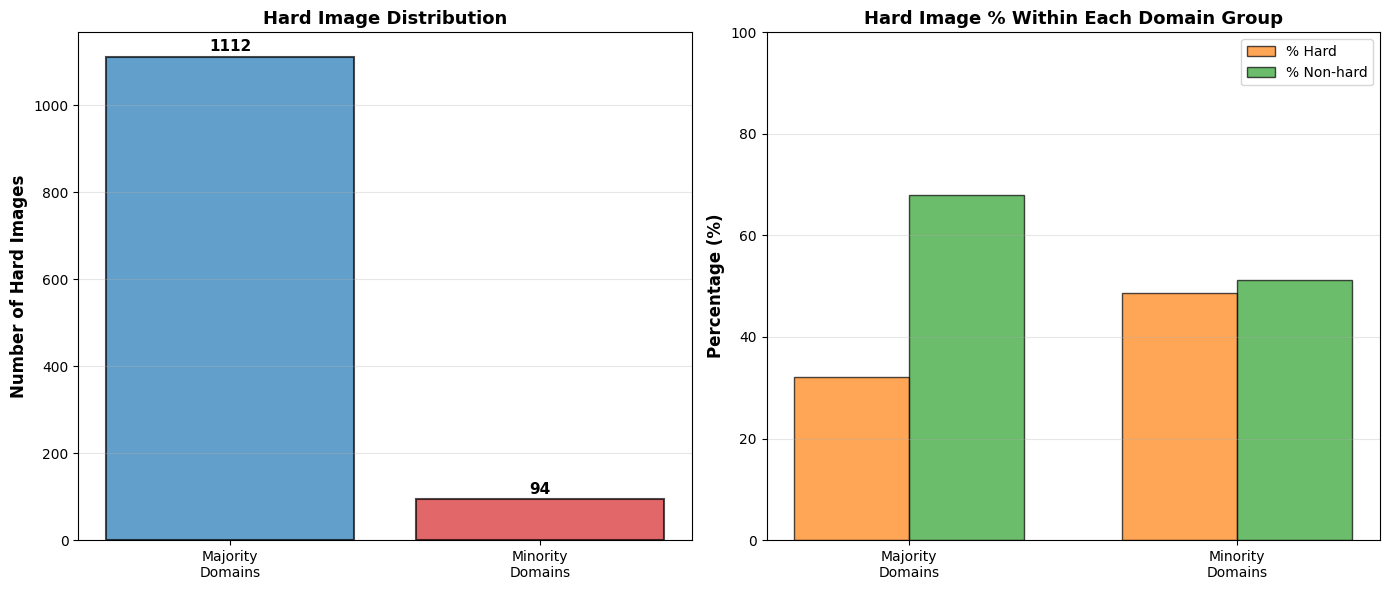


DIAGNOSTIC SUMMARY: Stochastic Instability Check

Minority domains contain 5.3% of all training images
but 7.8% of all hard images.

Concentration factor: 1.48x

✗ DIAGNOSIS: No strong clustering in minority domains
Hard images are distributed across all domains relatively evenly.


In [14]:
# Summary bar chart: hard image distribution (majority vs minority domains)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: counts
categories = ['Majority\nDomains', 'Minority\nDomains']
hard_counts = [hard_in_majority, hard_in_minority]
colors_bar = ['#1f77b4', '#d62728']

ax1.bar(categories, hard_counts, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Hard Images', fontsize=12, fontweight='bold')
ax1.set_title('Hard Image Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(hard_counts):
    ax1.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Right: percentages (pie chart style comparison)
all_images_majority = total_in_majority
all_images_minority = total_in_minority
x_pos = np.arange(2)
width = 0.35

ax2.bar(x_pos - width/2, [100*hard_in_majority/total_in_majority, 100*hard_in_minority/total_in_minority],
       width, label='% Hard', color='#ff7f0e', alpha=0.7, edgecolor='black', linewidth=1)
ax2.bar(x_pos + width/2, [100*(total_in_majority-hard_in_majority)/total_in_majority, 
                          100*(total_in_minority-hard_in_minority)/total_in_minority],
       width, label='% Non-hard', color='#2ca02c', alpha=0.7, edgecolor='black', linewidth=1)

ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Hard Image % Within Each Domain Group', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_hard_image_summary.png', dpi=200, bbox_inches='tight')
print(f"Saved summary plot to results/gwhd_2021_hard_image_summary.png")
plt.show()

# Final diagnosis
print("\n" + "="*70)
print("DIAGNOSTIC SUMMARY: Stochastic Instability Check")
print("="*70)
print(f"\nMinority domains contain {pct_minority:.1f}% of all training images")
print(f"but {pct_hard_in_minority:.1f}% of all hard images.")
print(f"\nConcentration factor: {pct_hard_in_minority/pct_minority:.2f}x")

if pct_hard_in_minority > 50:
    print("\n✓✓✓ DIAGNOSIS: STOCHASTIC INSTABILITY RISK")
    print("Hard images cluster in minority domains. Score-guided augmentation")
    print("will oversample these minority domains, creating high-variance signals")
    print("sensitive to training order (seed-dependent performance).")
else:
    print("\n✗ DIAGNOSIS: No strong clustering in minority domains")
    print("Hard images are distributed across all domains relatively evenly.")


In [15]:
# Analyze score distribution clustering by domain
# Which domains have difficulty scores concentrated at higher values?

# Calculate concentration metrics for each domain
domain_score_dist = []
for domain in df_scores['domain'].unique():
    domain_data = df_scores[df_scores['domain'] == domain]['difficulty_score']
    domain_score_dist.append({
        'domain': domain,
        'n_images': len(domain_data),
        'mean_score': domain_data.mean(),
        'median_score': domain_data.median(),
        'std_score': domain_data.std(),
        'min_score': domain_data.min(),
        'max_score': domain_data.max(),
        '25th_pct': domain_data.quantile(0.25),
        '75th_pct': domain_data.quantile(0.75),
        '90th_pct': domain_data.quantile(0.90),
        'pct_above_75th_global': 100 * (domain_data >= df_scores['difficulty_score'].quantile(0.75)).sum() / len(domain_data)
    })

score_dist_df = pd.DataFrame(domain_score_dist).sort_values('mean_score', ascending=False)

print("\n=== Domain Score Distribution (ranked by mean difficulty) ===")
print(score_dist_df[['domain', 'n_images', 'mean_score', 'median_score', 'std_score', '90th_pct', 'pct_above_75th_global']].to_string())
print("\n'pct_above_75th_global' = % of images in domain above the global 75th percentile score")



=== Domain Score Distribution (ranked by mean difficulty) ===
            domain  n_images  mean_score  median_score  std_score  90th_pct  pct_above_75th_global
6        Arvalis_4       204    0.498723      0.474919   0.099900  0.647796              92.647059
13      Arvalis_12        29    0.458143      0.395199   0.239595  0.544619              68.965517
10       Arvalis_1        66    0.434408      0.400363   0.135935  0.627366              59.090909
12       Arvalis_7        24    0.422059      0.406536   0.090326  0.534595              62.500000
3        Arvalis_2       401    0.396363      0.386081   0.077588  0.480130              50.872818
7   ULiège-GxABT_1        30    0.383169      0.380055   0.036919  0.432344              46.666667
15       Arvalis_9        32    0.372670      0.371833   0.051578  0.440227              43.750000
0       Arvalis_11        60    0.361629      0.358056   0.080470  0.462362              33.333333
1        Arvalis_3       588    0.356656      

Saved score distribution plot to results/gwhd_2021_score_distribution_by_domain.png


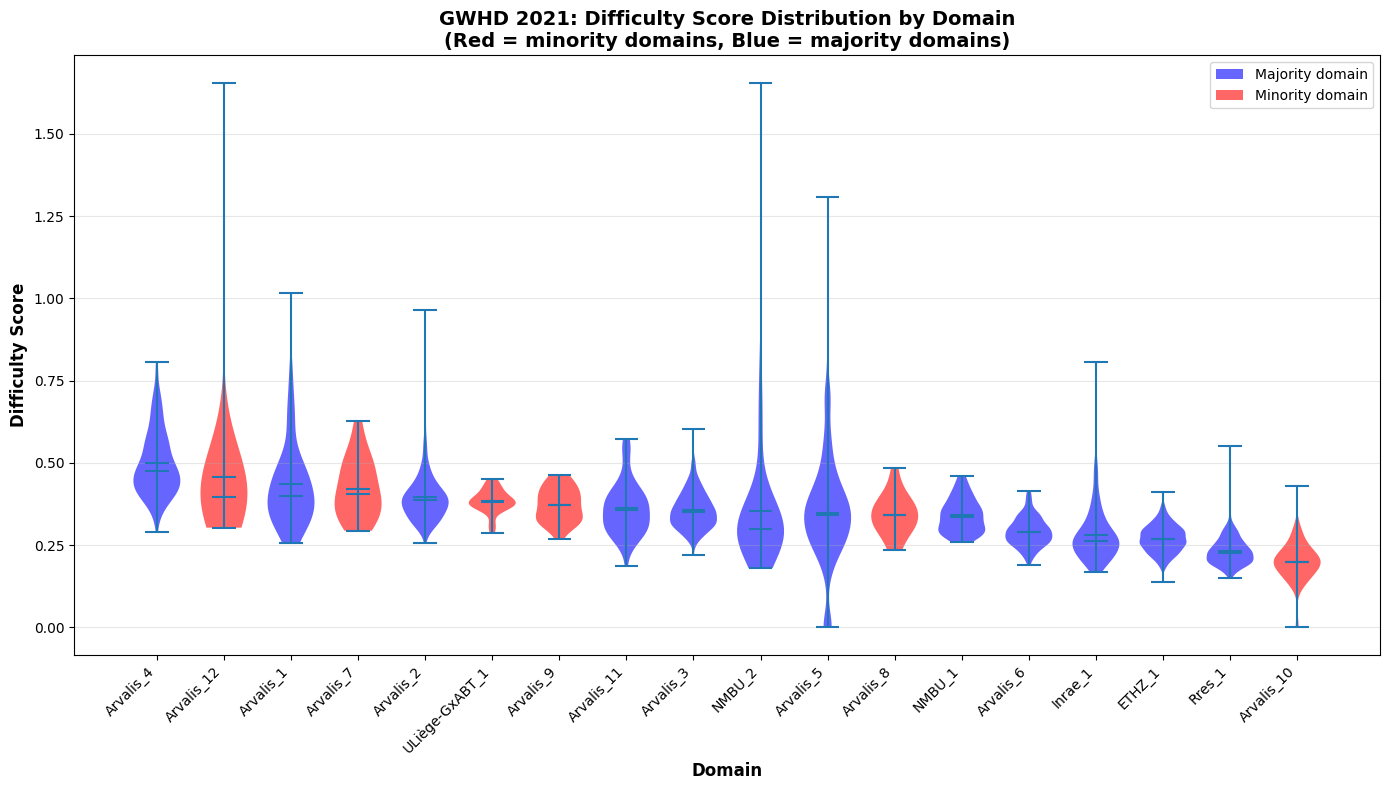

Saved mean score plot to results/gwhd_2021_mean_score_by_domain.png


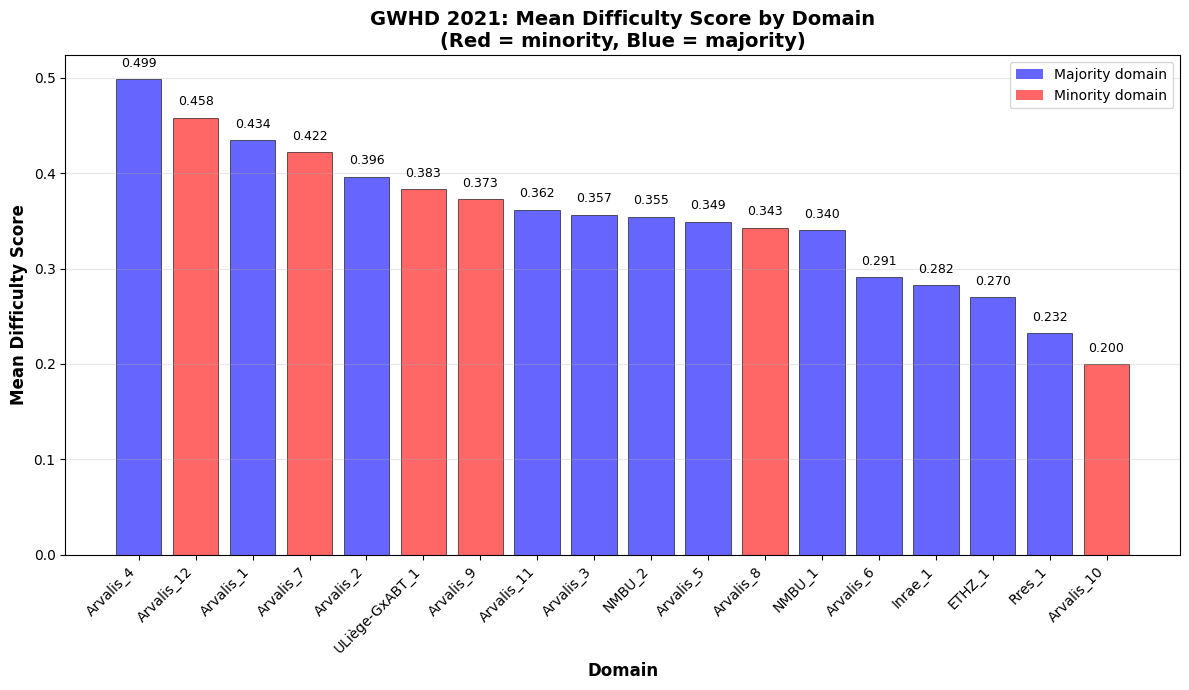

In [16]:
# Violin plot: score distribution by domain (sorted by mean score)
domains_sorted = score_dist_df['domain'].tolist()
df_scores_sorted = df_scores.copy()
df_scores_sorted['domain'] = pd.Categorical(df_scores_sorted['domain'], categories=domains_sorted, ordered=True)

fig, ax = plt.subplots(figsize=(14, 8))

# Create violin plot
parts = ax.violinplot([df_scores[df_scores['domain'] == d]['difficulty_score'].values for d in domains_sorted],
                       positions=range(len(domains_sorted)),
                       showmeans=True, showmedians=True, widths=0.7)

# Color violins by whether domain is minority
colors = ['red' if d in minority_domains else 'blue' for d in domains_sorted]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)

ax.set_xticks(range(len(domains_sorted)))
ax.set_xticklabels(domains_sorted, rotation=45, ha='right')
ax.set_ylabel('Difficulty Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Domain', fontsize=12, fontweight='bold')
ax.set_title('GWHD 2021: Difficulty Score Distribution by Domain\n(Red = minority domains, Blue = majority domains)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Majority domain'),
                   Patch(facecolor='red', alpha=0.6, label='Minority domain')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_score_distribution_by_domain.png', dpi=200, bbox_inches='tight')
print("Saved score distribution plot to results/gwhd_2021_score_distribution_by_domain.png")
plt.show()

# Bar plot: mean score by domain
fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['red' if d in minority_domains else 'blue' for d in domains_sorted]
bars = ax.bar(range(len(domains_sorted)), score_dist_df['mean_score'].values, color=colors_bar, alpha=0.6, edgecolor='black', linewidth=0.7)

ax.set_xticks(range(len(domains_sorted)))
ax.set_xticklabels(domains_sorted, rotation=45, ha='right')
ax.set_ylabel('Mean Difficulty Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Domain', fontsize=12, fontweight='bold')
ax.set_title('GWHD 2021: Mean Difficulty Score by Domain\n(Red = minority, Blue = majority)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, score_dist_df['mean_score'].values)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=9)

legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Majority domain'),
                   Patch(facecolor='red', alpha=0.6, label='Minority domain')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_mean_score_by_domain.png', dpi=200, bbox_inches='tight')
print("Saved mean score plot to results/gwhd_2021_mean_score_by_domain.png")
plt.show()



=== Score Clustering by Domain (% of images in each score range) ===
                Very Low (0.0-0.2)  Low (0.2-0.4)  Medium (0.4-0.6)  \
Arvalis_4                      0.0           11.8              72.1   
Arvalis_12                     0.0           55.2              41.4   
Arvalis_1                      0.0           50.0              37.9   
Arvalis_7                      0.0           45.8              50.0   
Arvalis_2                      0.0           61.3              36.2   
ULiège-GxABT_1                 0.0           70.0              30.0   
Arvalis_9                      0.0           68.8              31.2   
Arvalis_11                     1.7           71.7              26.7   
Arvalis_3                      0.0           78.4              21.4   
NMBU_2                         3.1           80.6               8.2   
Arvalis_5                     11.4           59.2              22.3   
Arvalis_8                      0.0           85.0              15.0   
NMBU_1 

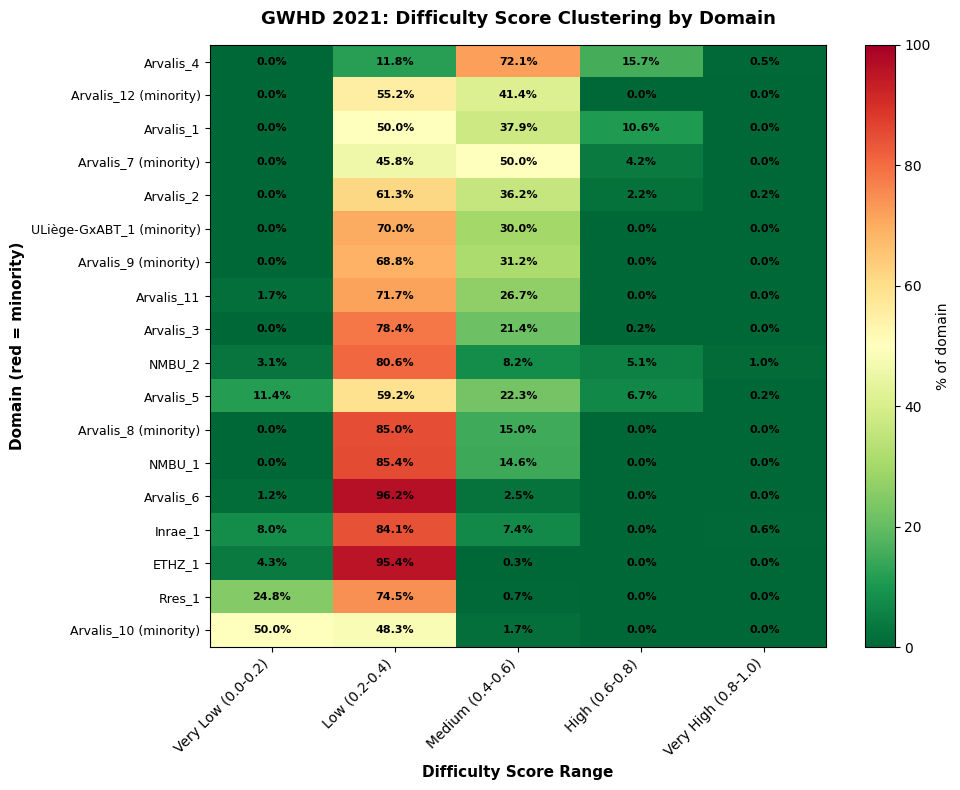


=== Domain Score Concentration Summary ===
Domains with HIGHEST concentration in high difficulty (0.6-1.0):

  Arvalis_4: 16.2% in high difficulty range
  Arvalis_1: 10.6% in high difficulty range
  Arvalis_5: 6.9% in high difficulty range
  NMBU_2: 6.1% in high difficulty range
  Arvalis_7: 4.2% in high difficulty range [MINORITY]
  Arvalis_2: 2.5% in high difficulty range
  Inrae_1: 0.6% in high difficulty range
  Arvalis_3: 0.2% in high difficulty range
  Arvalis_12: 0.0% in high difficulty range [MINORITY]
  ULiège-GxABT_1: 0.0% in high difficulty range [MINORITY]
  Arvalis_9: 0.0% in high difficulty range [MINORITY]
  Arvalis_11: 0.0% in high difficulty range
  NMBU_1: 0.0% in high difficulty range
  Arvalis_8: 0.0% in high difficulty range [MINORITY]
  Arvalis_6: 0.0% in high difficulty range
  ETHZ_1: 0.0% in high difficulty range
  Rres_1: 0.0% in high difficulty range
  Arvalis_10: 0.0% in high difficulty range [MINORITY]


In [17]:
# Heatmap: score clustering by domain
# Show what % of each domain falls into different score ranges

score_ranges = {
    'Very Low (0.0-0.2)': (0.0, 0.2),
    'Low (0.2-0.4)': (0.2, 0.4),
    'Medium (0.4-0.6)': (0.4, 0.6),
    'High (0.6-0.8)': (0.6, 0.8),
    'Very High (0.8-1.0)': (0.8, 1.0)
}

clustering_data = []
for domain in domains_sorted:
    domain_scores = df_scores[df_scores['domain'] == domain]['difficulty_score']
    range_pcts = {}
    for range_name, (low, high) in score_ranges.items():
        pct = 100 * ((domain_scores >= low) & (domain_scores < high)).sum() / len(domain_scores)
        range_pcts[range_name] = pct
    clustering_data.append(range_pcts)

clustering_df = pd.DataFrame(clustering_data, index=domains_sorted)

print("\n=== Score Clustering by Domain (% of images in each score range) ===")
print(clustering_df.round(1))

# Heatmap
fig, ax = plt.subplots(figsize=(10, max(8, len(domains_sorted)*0.25)))

im = ax.imshow(clustering_df.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(score_ranges)))
ax.set_yticks(range(len(domains_sorted)))
ax.set_xticklabels(list(score_ranges.keys()), rotation=45, ha='right')
ax.set_yticklabels([f"{d} (minority)" if d in minority_domains else f"{d}" for d in domains_sorted], fontsize=9)

# Add text annotations
for i in range(len(domains_sorted)):
    for j in range(len(score_ranges)):
        text = ax.text(j, i, f'{clustering_df.values[i, j]:.1f}%',
                      ha="center", va="center", color="black", fontsize=8, fontweight='bold')

ax.set_title('GWHD 2021: Difficulty Score Clustering by Domain', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Domain (red = minority)', fontsize=11, fontweight='bold')
ax.set_xlabel('Difficulty Score Range', fontsize=11, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='% of domain')

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_score_clustering_heatmap.png', dpi=200, bbox_inches='tight')
print("\nSaved clustering heatmap to results/gwhd_2021_score_clustering_heatmap.png")
plt.show()

# Summary: identify which domains have highest concentration in high difficulty
print("\n=== Domain Score Concentration Summary ===")
print("Domains with HIGHEST concentration in high difficulty (0.6-1.0):\n")
high_difficulty_pct = clustering_df[['High (0.6-0.8)', 'Very High (0.8-1.0)']].sum(axis=1).sort_values(ascending=False)
for domain, pct in high_difficulty_pct.items():
    is_minority = " [MINORITY]" if domain in minority_domains else ""
    print(f"  {domain}: {pct:.1f}% in high difficulty range{is_minority}")


In [19]:
# Analyze image and object characteristics by domain
# Load annotations from the training CSV to understand object sizes and counts

from collections import defaultdict

# The GWHD CSV stores boxes directly in BoxesString as "x1 y1 x2 y2;..."
# Use it instead of a missing labels/train directory so the notebook is self-contained.
boxes_by_image = train_df.set_index('image_name')['BoxesString']
domain_image_stats = defaultdict(lambda: {'n_images': 0, 'total_objects': 0, 'object_sizes': [], 'objects_per_image': []})

for row in train_df.itertuples(index=False):
    image_name = row.image_name
    domain = row.domain
    boxes_string = row.BoxesString

    if not isinstance(boxes_string, str) or not boxes_string.strip():
        continue

    object_sizes = []
    boxes = [box.strip() for box in boxes_string.split(';') if box.strip()]
    for box in boxes:
        parts = box.split()
        if len(parts) >= 4:
            x1, y1, x2, y2 = map(float, parts[:4])
            width = max(x2 - x1, 0.0)
            height = max(y2 - y1, 0.0)
            # Normalize by the 1024x1024 GWHD canvas so the thresholds below stay meaningful.
            size = (width * height) / (1024.0 * 1024.0)
            object_sizes.append(size)

    n_objects = len(object_sizes)
    domain_image_stats[domain]['n_images'] += 1
    domain_image_stats[domain]['total_objects'] += n_objects
    domain_image_stats[domain]['object_sizes'].extend(object_sizes)
    domain_image_stats[domain]['objects_per_image'].append(n_objects)

# Compute statistics per domain
domain_object_stats = []
for domain in domains_sorted:
    if domain in domain_image_stats:
        stats = domain_image_stats[domain]
        sizes = np.array(stats['object_sizes'])
        objects_per_img = np.array(stats['objects_per_image'])

        domain_object_stats.append({
            'domain': domain,
            'n_images': stats['n_images'],
            'total_objects': stats['total_objects'],
            'avg_objects_per_image': objects_per_img.mean() if len(objects_per_img) > 0 else 0,
            'median_objects_per_image': np.median(objects_per_img) if len(objects_per_img) > 0 else 0,
            'avg_object_size': sizes.mean() if len(sizes) > 0 else 0,
            'median_object_size': np.median(sizes) if len(sizes) > 0 else 0,
            'std_object_size': sizes.std() if len(sizes) > 0 else 0,
            'min_object_size': sizes.min() if len(sizes) > 0 else 0,
            'max_object_size': sizes.max() if len(sizes) > 0 else 0,
            'pct_small_objects': 100 * (sizes < 0.01).sum() / len(sizes) if len(sizes) > 0 else 0,
            'pct_medium_objects': 100 * ((sizes >= 0.01) & (sizes < 0.05)).sum() / len(sizes) if len(sizes) > 0 else 0,
            'pct_large_objects': 100 * (sizes >= 0.05).sum() / len(sizes) if len(sizes) > 0 else 0,
        })

object_stats_df = pd.DataFrame(domain_object_stats)

if object_stats_df.empty:
    raise RuntimeError('No domain object statistics were computed from BoxesString.')

print('\n=== Domain Object Statistics (sorted by mean score) ===')
print(object_stats_df[['domain', 'n_images', 'total_objects', 'avg_objects_per_image',
                       'avg_object_size', 'pct_small_objects', 'pct_medium_objects', 'pct_large_objects']].to_string())


=== Domain Object Statistics (sorted by mean score) ===
            domain  n_images  total_objects  avg_objects_per_image  avg_object_size  pct_small_objects  pct_medium_objects  pct_large_objects
0        Arvalis_4       204           4270              20.931373         0.005106          92.857143            7.142857           0.000000
1       Arvalis_12        29           1277              44.034483         0.003696          97.024276            2.975724           0.000000
2        Arvalis_1        66           2935              44.469697         0.003706          96.865417            3.134583           0.000000
3        Arvalis_7        24           1247              51.958333         0.004058          95.429030            4.570970           0.000000
4        Arvalis_2       401          21003              52.376559         0.005105          93.443794            6.556206           0.000000
5   ULiège-GxABT_1        30           1847              61.566667         0.011602        


=== Correlations with Mean Difficulty Score ===
  std_object_size....................  -0.364
  pct_medium_objects.................  -0.333
  pct_small_objects..................   0.320
  avg_object_size....................  -0.298
  pct_large_objects..................  -0.070
  avg_objects_per_image..............  -0.011

Saved correlation plot to results/gwhd_2021_feature_difficulty_correlation.png


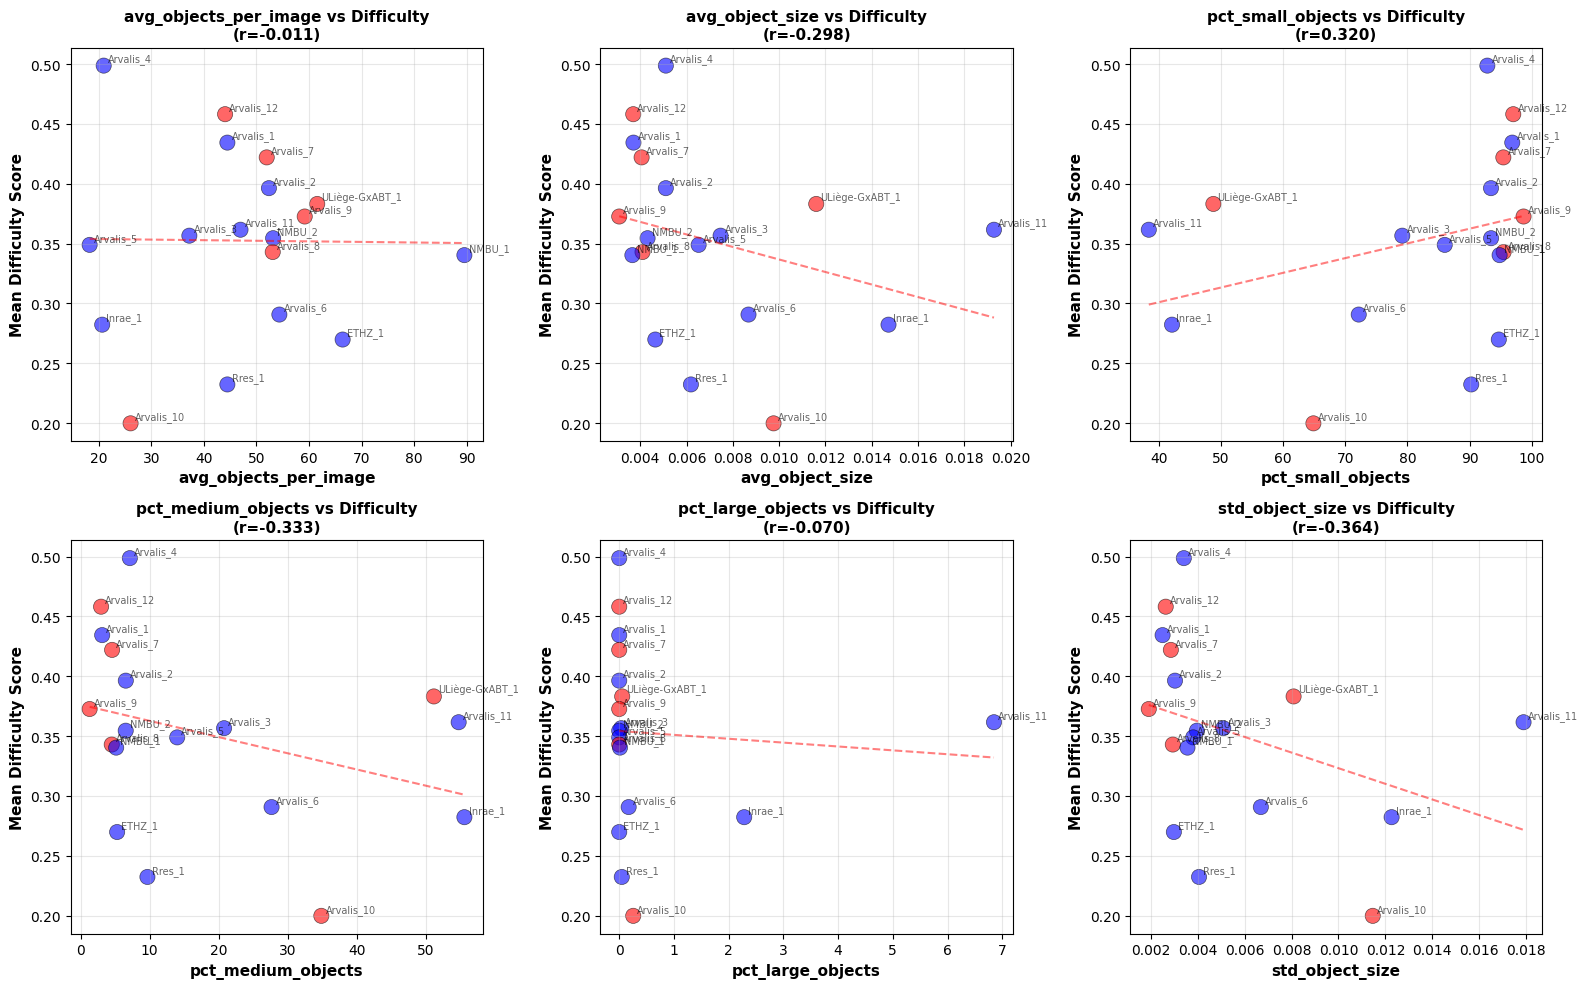

In [20]:
# Merge object stats with score stats and check for correlations
merged_stats = object_stats_df.merge(
    score_dist_df[['domain', 'mean_score', '90th_pct', 'pct_above_75th_global']],
    on='domain'
)

# Compute correlations with mean difficulty score
correlations = {
    'avg_objects_per_image': merged_stats['avg_objects_per_image'].corr(merged_stats['mean_score']),
    'avg_object_size': merged_stats['avg_object_size'].corr(merged_stats['mean_score']),
    'pct_small_objects': merged_stats['pct_small_objects'].corr(merged_stats['mean_score']),
    'pct_medium_objects': merged_stats['pct_medium_objects'].corr(merged_stats['mean_score']),
    'pct_large_objects': merged_stats['pct_large_objects'].corr(merged_stats['mean_score']),
    'std_object_size': merged_stats['std_object_size'].corr(merged_stats['mean_score']),
}

print("\n=== Correlations with Mean Difficulty Score ===")
for feature, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feature:.<35} {corr:>7.3f}")

# Visualization: scatter plots of key features vs mean difficulty score
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_to_plot = ['avg_objects_per_image', 'avg_object_size', 'pct_small_objects', 
                     'pct_medium_objects', 'pct_large_objects', 'std_object_size']
colors_scatter = ['red' if d in minority_domains else 'blue' for d in merged_stats['domain']]

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    ax.scatter(merged_stats[feature], merged_stats['mean_score'], 
               s=120, alpha=0.6, c=colors_scatter, edgecolors='black', linewidth=0.5)
    
    # Add domain labels
    for _, row in merged_stats.iterrows():
        ax.annotate(row['domain'], (row[feature], row['mean_score']), 
                   xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.6)
    
    # Add trendline
    z = np.polyfit(merged_stats[feature], merged_stats['mean_score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged_stats[feature].min(), merged_stats[feature].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=1.5)
    
    corr = correlations[feature]
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Difficulty Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{feature} vs Difficulty\n(r={corr:.3f})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_feature_difficulty_correlation.png', dpi=200, bbox_inches='tight')
print("\nSaved correlation plot to results/gwhd_2021_feature_difficulty_correlation.png")
plt.show()


In [21]:
# Load baseline model predictions to calculate per-domain AP scores
# Check if validation results are available
val_results_path = Path('/home/khanh/Projects/DifficultyAgri/results/02_only_scoring_gwhd_2021/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/results.json')

domain_ap_stats = {}

# Try to load COCO-format results if available
try:
    with open(val_results_path) as f:
        val_data = json.load(f)
    print(f"Loaded validation results from {val_results_path}")
    print(f"Keys: {list(val_data.keys())}")
    
    if 'results' in val_data:
        results = val_data['results']
        print(f"\nOverall AP metrics:")
        for key, val in results.items():
            print(f"  {key}: {val:.4f}")
except FileNotFoundError:
    print(f"Results file not found at {val_results_path}")
    val_data = None

# Alternatively, try to get per-domain stats from the annotations
# by calculating AP using the predictions from the baseline model
val_annotation_dir = Path('/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/val/labels')

if val_annotation_dir.exists():
    print(f"\nFound validation annotations at {val_annotation_dir}")
    
    # Create domain AP dictionary
    for domain in domains_sorted:
        domain_ap_stats[domain] = {
            'n_val_images': 0,
            'n_val_objects': 0,
        }
    
    # Count validation objects per domain
    val_annotation_files = list(val_annotation_dir.glob('*.txt'))
    val_csv_path = Path('/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/raw_v2/gwhd_2021/competition_val.csv')
    
    if val_csv_path.exists():
        val_df = pd.read_csv(val_csv_path)
        val_filename_to_domain = dict(zip(val_df['image_name'], val_df['domain']))
        
        for ann_file in val_annotation_files:
            img_name = ann_file.stem
            domain = val_filename_to_domain.get(img_name)
            
            if domain and domain in domain_ap_stats:
                with open(ann_file) as f:
                    n_objects = len(f.readlines())
                
                domain_ap_stats[domain]['n_val_images'] += 1
                domain_ap_stats[domain]['n_val_objects'] += n_objects
        
        print("\nValidation Object Statistics by Domain:")
        for domain in domains_sorted:
            if domain in domain_ap_stats:
                stats = domain_ap_stats[domain]
                print(f"  {domain:.<30} {stats['n_val_images']:>3} images, {stats['n_val_objects']:>4} objects")


Results file not found at /home/khanh/Projects/DifficultyAgri/results/02_only_scoring_gwhd_2021/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/results.json


In [22]:
# Create comprehensive summary: why are certain domains harder?
# Link difficulty scores to image characteristics

summary_data = []
for domain in domains_sorted:
    # Get difficulty info
    score_info = score_dist_df[score_dist_df['domain'] == domain].iloc[0]
    
    # Get object info
    if domain in [d['domain'] for d in domain_object_stats]:
        obj_info = next(d for d in domain_object_stats if d['domain'] == domain)
    else:
        obj_info = None
    
    # Get validation info
    val_info = domain_ap_stats.get(domain, {})
    
    is_minority = domain in minority_domains
    is_high_score = score_info['mean_score'] >= score_dist_df['mean_score'].quantile(0.67)
    
    summary_data.append({
        'domain': domain,
        'minority': '✓' if is_minority else '✗',
        'high_score': '✓' if is_high_score else '✗',
        'mean_score': score_info['mean_score'],
        'n_train_imgs': obj_info['n_images'] if obj_info else 0,
        'avg_objs_per_img': f"{obj_info['avg_objects_per_image']:.2f}" if obj_info else 'N/A',
        'avg_obj_size': f"{obj_info['avg_object_size']:.4f}" if obj_info else 'N/A',
        'pct_small': f"{obj_info['pct_small_objects']:.1f}%" if obj_info else 'N/A',
        'pct_medium': f"{obj_info['pct_medium_objects']:.1f}%" if obj_info else 'N/A',
        'pct_large': f"{obj_info['pct_large_objects']:.1f}%" if obj_info else 'N/A',
        'n_val_imgs': val_info.get('n_val_images', 0),
        'n_val_objs': val_info.get('n_val_objects', 0),
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*150)
print("COMPREHENSIVE DOMAIN ANALYSIS: Why are certain domains harder?")
print("="*150)
print(summary_df.to_string(index=False))
print("\n" + "="*150)

# Highlight patterns
print("\nKEY PATTERNS:")
print("-" * 80)

# Find hardest domains
hardest = merged_stats.nlargest(3, 'mean_score')[['domain', 'mean_score', 'avg_objects_per_image', 'avg_object_size', 'pct_small_objects']]
print("\nHARDEST DOMAINS (top 3 by mean difficulty score):")
for _, row in hardest.iterrows():
    print(f"\n  {row['domain']}:")
    print(f"    - Mean difficulty: {row['mean_score']:.4f}")
    print(f"    - Avg objects/image: {row['avg_objects_per_image']:.2f}")
    print(f"    - Avg object size: {row['avg_object_size']:.4f}")
    print(f"    - % small objects: {row['pct_small_objects']:.1f}%")
    
    # Infer why it's hard
    reasons = []
    if row['avg_object_size'] < merged_stats['avg_object_size'].quantile(0.33):
        reasons.append("MANY SMALL OBJECTS")
    if row['pct_small_objects'] > merged_stats['pct_small_objects'].quantile(0.67):
        reasons.append("HIGH % SMALL")
    if row['avg_objects_per_image'] < merged_stats['avg_objects_per_image'].quantile(0.33):
        reasons.append("FEW OBJECTS (sparse)")
    if row['avg_objects_per_image'] > merged_stats['avg_objects_per_image'].quantile(0.67):
        reasons.append("MANY OBJECTS (dense)")
    
    if reasons:
        print(f"    - Likely reasons: {', '.join(reasons)}")

# Find easiest domains
easiest = merged_stats.nsmallest(3, 'mean_score')[['domain', 'mean_score', 'avg_objects_per_image', 'avg_object_size', 'pct_large_objects']]
print("\n\nEASIEST DOMAINS (bottom 3 by mean difficulty score):")
for _, row in easiest.iterrows():
    print(f"\n  {row['domain']}:")
    print(f"    - Mean difficulty: {row['mean_score']:.4f}")
    print(f"    - Avg objects/image: {row['avg_objects_per_image']:.2f}")
    print(f"    - Avg object size: {row['avg_object_size']:.4f}")
    print(f"    - % large objects: {row['pct_large_objects']:.1f}%")



COMPREHENSIVE DOMAIN ANALYSIS: Why are certain domains harder?
        domain minority high_score  mean_score  n_train_imgs avg_objs_per_img avg_obj_size pct_small pct_medium pct_large  n_val_imgs  n_val_objs
     Arvalis_4        ✗          ✓    0.498723           204            20.93       0.0051     92.9%       7.1%      0.0%           0           0
    Arvalis_12        ✓          ✓    0.458143            29            44.03       0.0037     97.0%       3.0%      0.0%           0           0
     Arvalis_1        ✗          ✓    0.434408            66            44.47       0.0037     96.9%       3.1%      0.0%           0           0
     Arvalis_7        ✓          ✓    0.422059            24            51.96       0.0041     95.4%       4.6%      0.0%           0           0
     Arvalis_2        ✗          ✓    0.396363           401            52.38       0.0051     93.4%       6.6%      0.0%           0           0
ULiège-GxABT_1        ✓          ✓    0.383169            30

Saved bubble chart to results/gwhd_2021_domain_characteristics_bubble.png


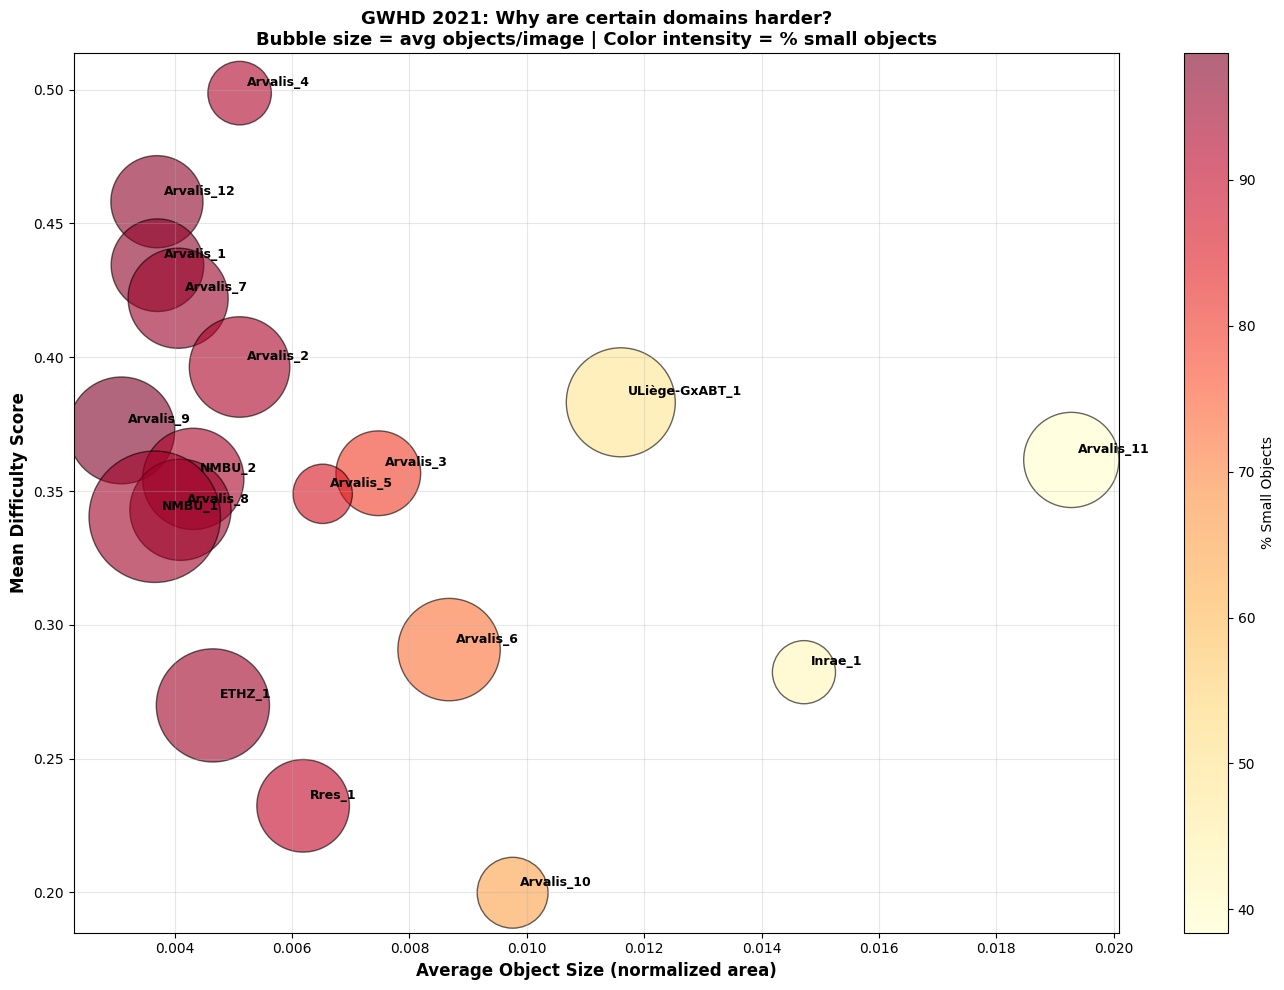

Saved profile comparison to results/gwhd_2021_domain_profile_comparison.png


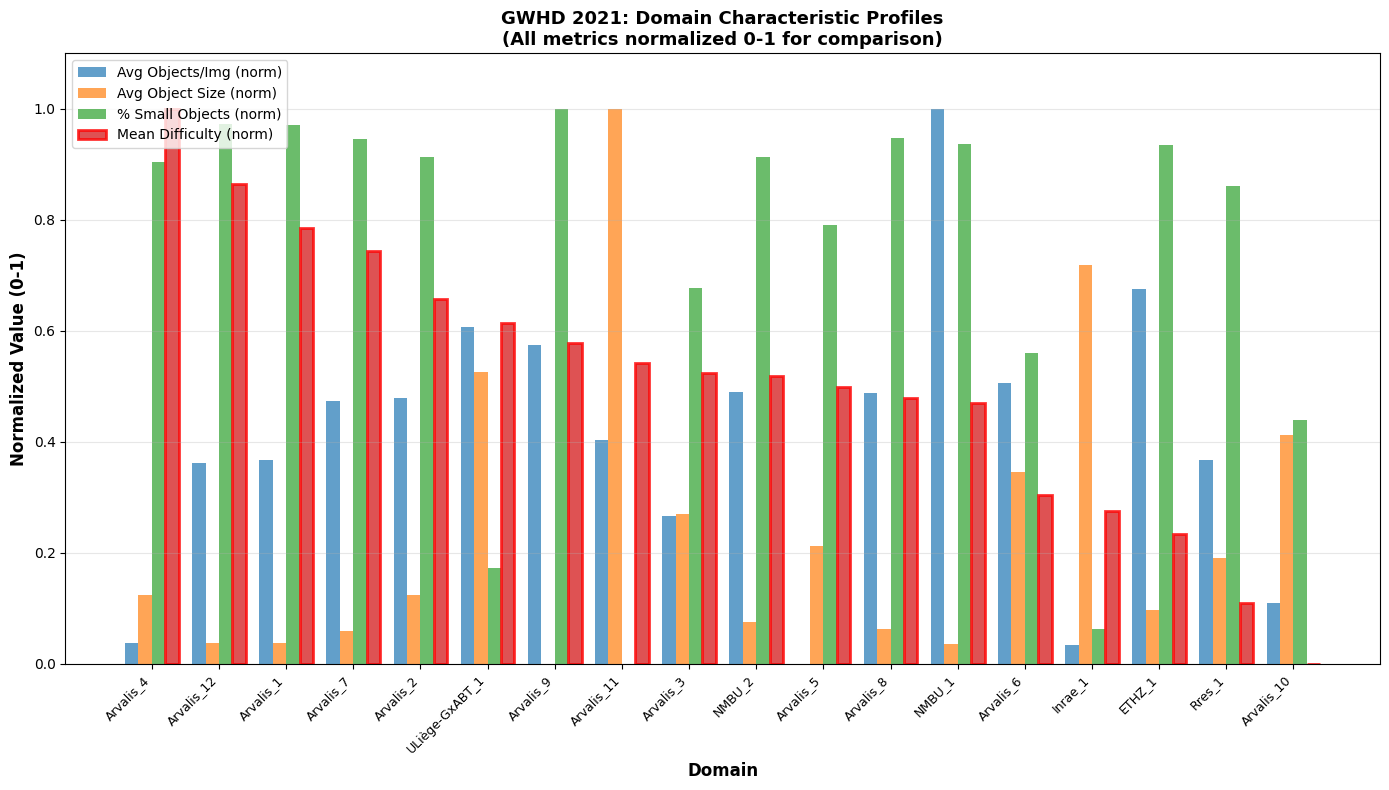

In [23]:
# Create a bubble chart showing relationships between multiple characteristics
fig, ax = plt.subplots(figsize=(14, 10))

# X: avg object size, Y: mean difficulty score, Bubble size: avg objects per image, Color: pct small objects
scatter = ax.scatter(
    merged_stats['avg_object_size'],
    merged_stats['mean_score'],
    s=merged_stats['avg_objects_per_image']*100,  # Size represents objects per image
    c=merged_stats['pct_small_objects'],  # Color represents % small objects
    cmap='YlOrRd',
    alpha=0.6,
    edgecolors='black',
    linewidth=1
)

# Add domain labels
for _, row in merged_stats.iterrows():
    ax.annotate(row['domain'], 
               (row['avg_object_size'], row['mean_score']),
               xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_xlabel('Average Object Size (normalized area)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Difficulty Score', fontsize=12, fontweight='bold')
ax.set_title('GWHD 2021: Why are certain domains harder?\nBubble size = avg objects/image | Color intensity = % small objects', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='% Small Objects')

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_domain_characteristics_bubble.png', dpi=200, bbox_inches='tight')
print("Saved bubble chart to results/gwhd_2021_domain_characteristics_bubble.png")
plt.show()

# Parallel coordinates-like visualization: normalize all metrics and show patterns
normalized_metrics = merged_stats[['domain', 'avg_objects_per_image', 'avg_object_size', 
                                     'pct_small_objects', 'mean_score']].copy()

for col in ['avg_objects_per_image', 'avg_object_size', 'pct_small_objects', 'mean_score']:
    min_val = normalized_metrics[col].min()
    max_val = normalized_metrics[col].max()
    normalized_metrics[col] = (normalized_metrics[col] - min_val) / (max_val - min_val)

# Bar plot showing normalized profiles
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(normalized_metrics))
width = 0.2

bars1 = ax.bar(x - 1.5*width, normalized_metrics['avg_objects_per_image'], width, label='Avg Objects/Img (norm)', alpha=0.7)
bars2 = ax.bar(x - 0.5*width, normalized_metrics['avg_object_size'], width, label='Avg Object Size (norm)', alpha=0.7)
bars3 = ax.bar(x + 0.5*width, normalized_metrics['pct_small_objects'], width, label='% Small Objects (norm)', alpha=0.7)
bars4 = ax.bar(x + 1.5*width, normalized_metrics['mean_score'], width, label='Mean Difficulty (norm)', alpha=0.8, edgecolor='red', linewidth=2)

ax.set_xlabel('Domain', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
ax.set_title('GWHD 2021: Domain Characteristic Profiles\n(All metrics normalized 0-1 for comparison)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(normalized_metrics['domain'], rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_domain_profile_comparison.png', dpi=200, bbox_inches='tight')
print("Saved profile comparison to results/gwhd_2021_domain_profile_comparison.png")
plt.show()



=== Full Correlation Matrix (with Mean Difficulty Score) ===
                       mean_score
mean_score               1.000000
pct_small_objects        0.320414
avg_objects_per_image   -0.011240
pct_large_objects       -0.069774
n_images                -0.294234
avg_object_size         -0.298340
pct_medium_objects      -0.333250
std_object_size         -0.364416

Saved correlation matrix to results/gwhd_2021_correlation_matrix.png


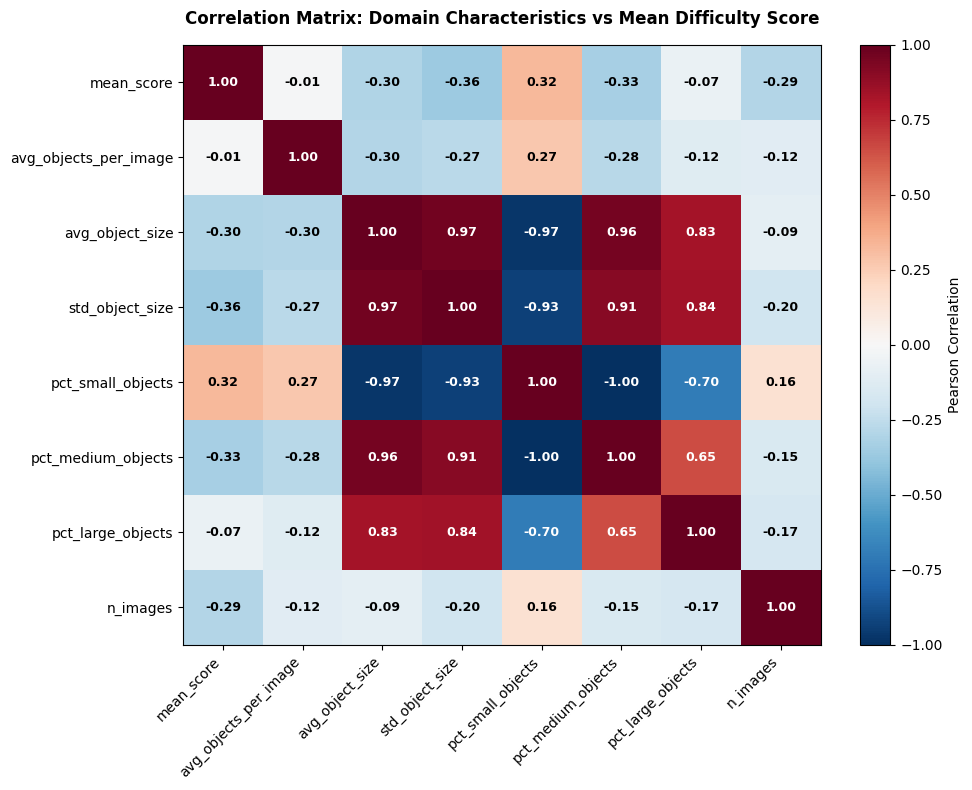


FINAL INTERPRETATION: What Makes GWHD 2021 Domains Hard?

Based on correlation analysis with difficulty scores:

◌ avg_object_size......................... (r=-0.298) - WEAK correlation
  → avg_object_size is NOT a strong driver of difficulty

✓ pct_small_objects....................... (r= 0.320) - POSITIVE correlation
  → Domains with more pct_small_objects tend to be HARDER

◌ avg_objects_per_image................... (r=-0.011) - WEAK correlation
  → avg_objects_per_image is NOT a strong driver of difficulty

✗ std_object_size......................... (r=-0.364) - NEGATIVE correlation
  → Domains with more std_object_size tend to be EASIER



In [24]:
# Final correlation matrix and heatmap: what drives difficulty?
correlation_data = merged_stats[[
    'mean_score', 'avg_objects_per_image', 'avg_object_size', 'std_object_size',
    'pct_small_objects', 'pct_medium_objects', 'pct_large_objects', 'n_images'
]].copy()

# Compute full correlation matrix
corr_matrix = correlation_data.corr()

print("\n=== Full Correlation Matrix (with Mean Difficulty Score) ===")
print(corr_matrix[['mean_score']].sort_values('mean_score', ascending=False))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

ticks = range(len(corr_matrix.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr_matrix.columns, fontsize=10)

# Add text annotations
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                      ha="center", va="center", 
                      color="white" if abs(corr_matrix.values[i, j]) > 0.5 else "black",
                      fontsize=9, fontweight='bold')

ax.set_title('Correlation Matrix: Domain Characteristics vs Mean Difficulty Score', 
             fontsize=12, fontweight='bold', pad=15)

cbar = plt.colorbar(im, ax=ax, label='Pearson Correlation')

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/results/gwhd_2021_correlation_matrix.png', dpi=200, bbox_inches='tight')
print("\nSaved correlation matrix to results/gwhd_2021_correlation_matrix.png")
plt.show()

# Final interpretation
print("\n" + "="*80)
print("FINAL INTERPRETATION: What Makes GWHD 2021 Domains Hard?")
print("="*80)
print("\nBased on correlation analysis with difficulty scores:\n")

for feature in ['avg_object_size', 'pct_small_objects', 'avg_objects_per_image', 'std_object_size']:
    corr_val = corr_matrix.loc[feature, 'mean_score']
    if corr_val > 0.3:
        print(f"✓ {feature:.<40} (r={corr_val:>6.3f}) - POSITIVE correlation")
        print(f"  → Domains with more {feature} tend to be HARDER\n")
    elif corr_val < -0.3:
        print(f"✗ {feature:.<40} (r={corr_val:>6.3f}) - NEGATIVE correlation")
        print(f"  → Domains with more {feature} tend to be EASIER\n")
    else:
        print(f"◌ {feature:.<40} (r={corr_val:>6.3f}) - WEAK correlation")
        print(f"  → {feature} is NOT a strong driver of difficulty\n")

print("="*80)
